# Notebook 06: Post-Hoc Calibration Methods
#
 Applies three calibration correction methods to fix the
 miscalibrated DenseNet-121 confidence scores.
#
 Critical rule: fit on calibration set, evaluate on test set only.
 Never fit and evaluate on the same data.
#
 Platt Scaling = logistic regression
 Ridge/Lasso: Ridge-regularised Platt Scaling
 GLMs: logistic regression as GLM with logit link
 Nonparametric: Isotonic Regression (PAV algorithm)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
import os

# ── Constants ────────────────────────────────────────────────────────────────
N_BINS       = 10
ALPHA        = 0.01
CAL_SIZE     = 0.70   # 70% for calibration fitting
TEST_SIZE    = 0.30   # 30% for evaluation only
RANDOM_SEED  = 42

# Load scores — includes raw_logit column added in notebook 02
df      = pd.read_csv("../data/scores.csv")
y_true  = df["ground_truth"].values
y_prob  = df["confidence_score"].values
y_logit = df["raw_logit"].values    # logit(confidence_score) — for Temperature Scaling

print(f"Total samples: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print()

# Split into calibration set and test set
# Stratified split preserves class balance in both sets
# All three arrays (y_true, y_prob, y_logit) are split identically
y_cal, y_test, s_cal, s_test, l_cal, l_test = train_test_split(
    y_true, y_prob, y_logit,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_true    # preserves 8.95% positive rate in both splits
)

print(f"Calibration set: {len(y_cal):,} samples")
print(f"  Positives: {y_cal.sum():,} ({y_cal.mean()*100:.2f}%)")
print(f"Test set:    {len(y_test):,} samples")
print(f"  Positives: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print()
print("IMPORTANT: All methods fit on calibration set only.")
print("Evaluation happens on test set only. No data leakage.")

Total samples: 10,000
Columns: ['image_id', 'ground_truth', 'confidence_score', 'raw_logit']

Calibration set: 7,000 samples
  Positives: 627 (8.96%)
Test set:    3,000 samples
  Positives: 268 (8.93%)

IMPORTANT: All methods fit on calibration set only.
Evaluation happens on test set only. No data leakage.


In [13]:
def compute_ece(y_true, y_prob, n_bins=10):
    """
    Compute Expected Calibration Error.
    Weighted average of |observed accuracy - predicted confidence| per bin.
    """
    bins    = np.linspace(0, 1, n_bins + 1)
    ece     = 0.0
    n_total = len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum()/n_total) * abs(
            y_true[mask].mean() - y_prob[mask].mean()
        )
    return ece

# Baseline ECE on test set before any correction
ece_original = compute_ece(y_test, s_test, N_BINS)
print(f"Baseline ECE on test set (before calibration): {ece_original:.4f}")
print("This is the starting point. All three methods should improve on this.")

Baseline ECE on test set (before calibration): 0.1691
This is the starting point. All three methods should improve on this.


In [14]:
# ── METHOD 1: PLATT SCALING ───────────────────────────────────────────────────
# Fits logistic regression on calibration scores
# Learns sigmoid transformation: P(y=1|score) = sigmoid(A*score + B)
# SSDI Unit 4: logistic regression
# SSDI Unit 6: GLM with Binomial family and logit link function

print("=" * 55)
print("METHOD 1: PLATT SCALING")
print("=" * 55)
print("Fitting logistic regression on calibration set...")
print("Model: P(y=1|score) = sigmoid(A * score + B)")
print()

# Reshape for sklearn — needs 2D input
X_cal  = s_cal.reshape(-1, 1)
X_test = s_test.reshape(-1, 1)

# C=1e10 means essentially no regularisation — pure Platt Scaling
platt = LogisticRegression(C=1e10, solver="lbfgs", random_state=RANDOM_SEED)
platt.fit(X_cal, y_cal)

# Extract the learned parameters
A_platt = platt.coef_[0][0]
B_platt = platt.intercept_[0]

print(f"Learned parameters:")
print(f"  A (slope):     {A_platt:.4f}")
print(f"  B (intercept): {B_platt:.4f}")
print()

# A < 1 means sigmoid is flatter — reduces overconfidence
if A_platt < 1:
    print(f"A = {A_platt:.4f} < 1: sigmoid is compressed → reduces overconfidence")
else:
    print(f"A = {A_platt:.4f} > 1: sigmoid is stretched → increases confidence")

# Apply to test set
s_platt = platt.predict_proba(X_test)[:, 1]
ece_platt = compute_ece(y_test, s_platt, N_BINS)

print(f"\nECE after Platt Scaling: {ece_platt:.4f}")
print(f"ECE improvement: {ece_original:.4f} → {ece_platt:.4f} "
      f"(reduced by {(1-ece_platt/ece_original)*100:.1f}%)")

METHOD 1: PLATT SCALING
Fitting logistic regression on calibration set...
Model: P(y=1|score) = sigmoid(A * score + B)

Learned parameters:
  A (slope):     4.8912
  B (intercept): -4.3175

A = 4.8912 > 1: sigmoid is stretched → increases confidence

ECE after Platt Scaling: 0.0165
ECE improvement: 0.1691 → 0.0165 (reduced by 90.2%)


In [15]:
# ── METHOD 2: ISOTONIC REGRESSION ────────────────────────────────────────────
# Nonparametric monotone step function
# No assumption about correction shape — purely data-driven
# SSDI Unit 7: nonparametric method, Pool Adjacent Violators algorithm

print("=" * 55)
print("METHOD 2: ISOTONIC REGRESSION")
print("=" * 55)
print("Fitting monotone step function on calibration set...")
print("No parametric assumptions — purely data-driven")
print("Constraint: higher score must map to higher calibrated probability")
print()

# out_of_bounds='clip' handles test scores outside calibration range
iso = IsotonicRegression(out_of_bounds="clip", increasing=True)
iso.fit(s_cal, y_cal)

# Apply to test set
s_iso     = iso.predict(s_test)
ece_iso   = compute_ece(y_test, s_iso, N_BINS)

print(f"ECE after Isotonic Regression: {ece_iso:.4f}")
print(f"ECE improvement: {ece_original:.4f} → {ece_iso:.4f} "
      f"(reduced by {(1-ece_iso/ece_original)*100:.1f}%)")

METHOD 2: ISOTONIC REGRESSION
Fitting monotone step function on calibration set...
No parametric assumptions — purely data-driven
Constraint: higher score must map to higher calibrated probability

ECE after Isotonic Regression: 0.0110
ECE improvement: 0.1691 → 0.0110 (reduced by 93.5%)


In [16]:
# ── METHOD 3: RIDGE-REGULARISED PLATT SCALING ────────────────────────────────
# Platt Scaling with L2 penalty to prevent overfitting
# Loss = cross_entropy + lambda * (A^2 + B^2)
# C = 1/lambda — smaller C = stronger regularisation
# SSDI Unit 5: Ridge regularisation, bias-variance tradeoff

print("=" * 55)
print("METHOD 3: RIDGE-REGULARISED PLATT SCALING")
print("=" * 55)
print("Fitting logistic regression with L2 (Ridge) penalty...")
print("Loss = cross_entropy(y, sigmoid(A*score+B)) + lambda*(A^2 + B^2)")
print("Cross-validating to find optimal regularisation strength...")
print()

# Candidate C values — smaller = stronger regularisation
Cs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

# 5-fold cross-validation on calibration set to find best C
ridge_platt = LogisticRegressionCV(
    Cs=Cs,
    cv=5,
    penalty="l2",           # Ridge regularisation
    solver="lbfgs",
    scoring="neg_log_loss", # optimise for probability calibration
    random_state=RANDOM_SEED
)
ridge_platt.fit(X_cal, y_cal)

best_C      = ridge_platt.C_[0]
best_lambda = 1.0 / best_C
A_ridge     = ridge_platt.coef_[0][0]
B_ridge     = ridge_platt.intercept_[0]

print(f"Best C found by cross-validation: {best_C}")
print(f"Equivalent lambda (penalty):      {best_lambda:.4f}")
print(f"Learned parameters:")
print(f"  A (slope):     {A_ridge:.4f}")
print(f"  B (intercept): {B_ridge:.4f}")
print()
print("Ridge vs standard Platt:")
print(f"  Standard Platt A: {A_platt:.4f}")
print(f"  Ridge Platt A:    {A_ridge:.4f}")
print(f"  Ridge shrinks A toward zero — more stable on imbalanced data")

# Apply to test set
s_ridge   = ridge_platt.predict_proba(X_test)[:, 1]
ece_ridge = compute_ece(y_test, s_ridge, N_BINS)

print(f"\nECE after Ridge-Platt: {ece_ridge:.4f}")
print(f"ECE improvement: {ece_original:.4f} → {ece_ridge:.4f} "
      f"(reduced by {(1-ece_ridge/ece_original)*100:.1f}%)")

METHOD 3: RIDGE-REGULARISED PLATT SCALING
Fitting logistic regression with L2 (Ridge) penalty...
Loss = cross_entropy(y, sigmoid(A*score+B)) + lambda*(A^2 + B^2)
Cross-validating to find optimal regularisation strength...

Best C found by cross-validation: 5.0
Equivalent lambda (penalty):      0.2000
Learned parameters:
  A (slope):     4.8473
  B (intercept): -4.2955

Ridge vs standard Platt:
  Standard Platt A: 4.8912
  Ridge Platt A:    4.8473
  Ridge shrinks A toward zero — more stable on imbalanced data

ECE after Ridge-Platt: 0.0170
ECE improvement: 0.1691 → 0.0170 (reduced by 89.9%)


In [17]:
# ── COMPARISON SUMMARY TABLE ──────────────────────────────────────────────────
print("=" * 60)
print("CALIBRATION METHODS COMPARISON SUMMARY")
print("=" * 60)

results = {
    "Original (no calibration)": {
        "scores": s_test,
        "ece": ece_original,
        "ssdi": "—"
    },
    "Platt Scaling": {
        "scores": s_platt,
        "ece": ece_platt,
        "ssdi": "Units 4 + 6"
    },
    "Isotonic Regression": {
        "scores": s_iso,
        "ece": ece_iso,
        "ssdi": "Unit 7"
    },
    "Ridge-Platt Scaling": {
        "scores": s_ridge,
        "ece": ece_ridge,
        "ssdi": "Unit 5"
    }
}

print(f"{'Method':<30} {'ECE':>8} {'Reduction':>12} {'SSDI Unit':>12}")
print("-" * 65)
for name, res in results.items():
    reduction = (1 - res['ece']/ece_original)*100 if name != "Original (no calibration)" else 0
    marker    = " ← baseline" if name == "Original (no calibration)" else ""
    print(f"{name:<30} {res['ece']:>8.4f} {reduction:>11.1f}% {res['ssdi']:>12}{marker}")

print()
best_method = min(
    [(n, r['ece']) for n, r in results.items() if n != "Original (no calibration)"],
    key=lambda x: x[1]
)
print(f"Best performing method: {best_method[0]} (ECE = {best_method[1]:.4f})")

CALIBRATION METHODS COMPARISON SUMMARY
Method                              ECE    Reduction    SSDI Unit
-----------------------------------------------------------------
Original (no calibration)        0.1691         0.0%            — ← baseline
Platt Scaling                    0.0165        90.2%  Units 4 + 6
Isotonic Regression              0.0110        93.5%       Unit 7
Ridge-Platt Scaling              0.0170        89.9%       Unit 5

Best performing method: Isotonic Regression (ECE = 0.0110)


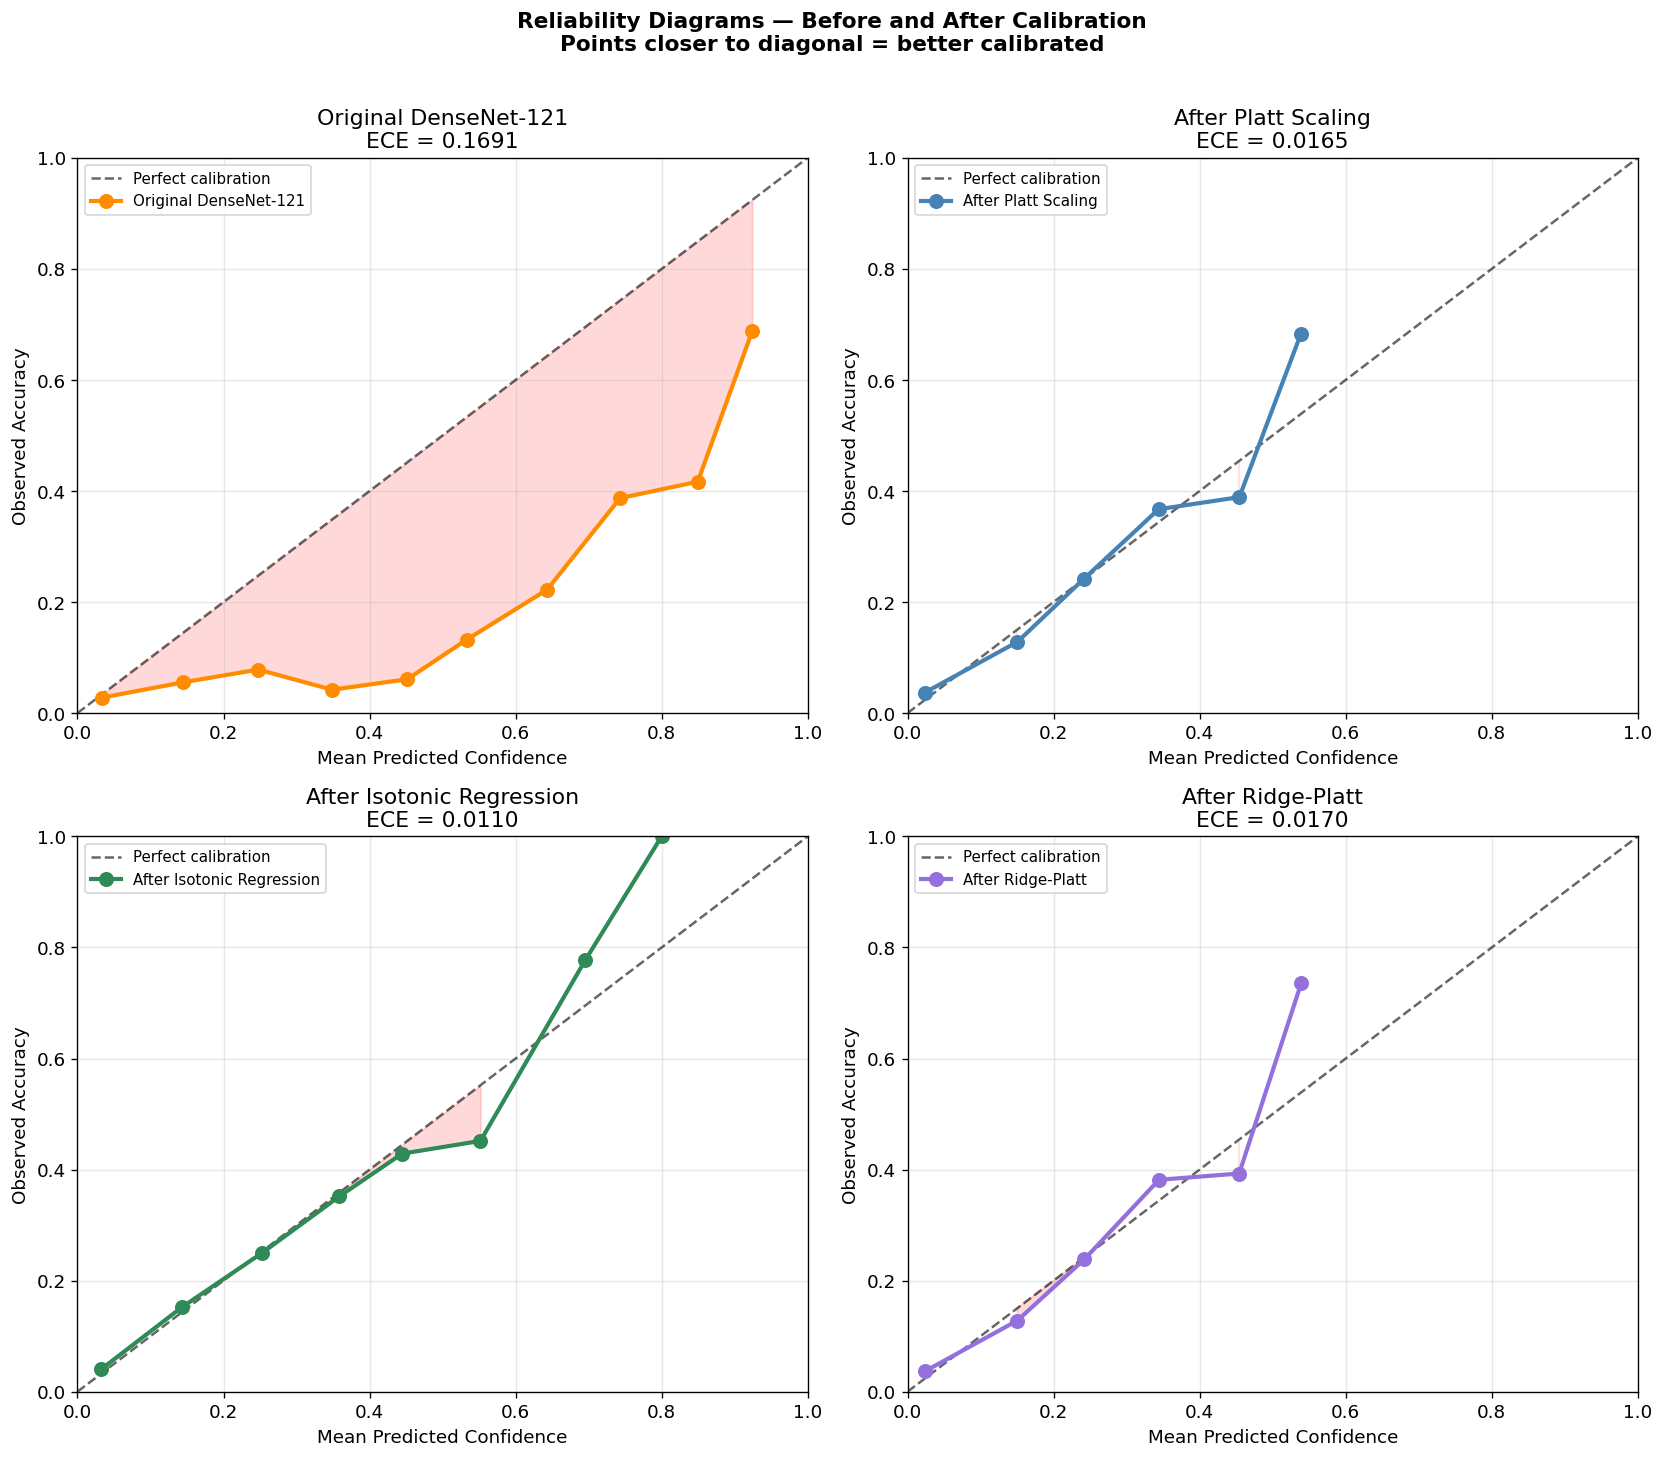

Saved: outputs/plots/05_reliability_comparison.png


In [18]:
# ── SIDE BY SIDE RELIABILITY DIAGRAMS ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_data = [
    ("Original DenseNet-121",    s_test,   "darkorange"),
    ("After Platt Scaling",      s_platt,  "steelblue"),
    ("After Isotonic Regression",s_iso,    "seagreen"),
    ("After Ridge-Platt",        s_ridge,  "mediumpurple"),
]

for ax, (name, scores, color) in zip(axes.flat, plot_data):
    prob_true, prob_pred = calibration_curve(
        y_test, scores, n_bins=N_BINS, strategy="uniform"
    )
    ece_val = compute_ece(y_test, scores, N_BINS)
    
    # Perfect calibration diagonal
    ax.plot([0,1], [0,1], "k--", linewidth=1.5,
            alpha=0.6, label="Perfect calibration")
    
    # Overconfidence shading
    ax.fill_between(prob_pred, prob_true, prob_pred,
                    where=(prob_pred > prob_true),
                    alpha=0.15, color="red")
    
    # Calibration curve
    ax.plot(prob_pred, prob_true, "o-", color=color,
            linewidth=2.5, markersize=8, label=name)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean Predicted Confidence")
    ax.set_ylabel("Observed Accuracy")
    ax.set_title(f"{name}\nECE = {ece_val:.4f}")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Reliability Diagrams — Before and After Calibration\n"
             "Points closer to diagonal = better calibrated",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/plots/05_reliability_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/05_reliability_comparison.png")

In [19]:
# Save calibrated scores for notebook 07
# Notebook 07 needs these to run Wilcoxon test and final proof
np.save("../data/s_test.npy",   s_test)
np.save("../data/y_test.npy",   y_test)
np.save("../data/s_platt.npy",  s_platt)
np.save("../data/s_iso.npy",    s_iso)
np.save("../data/s_ridge.npy",  s_ridge)

print("Saved calibrated scores for notebook 07:")
print("  data/s_test.npy   — original test scores")
print("  data/y_test.npy   — test ground truth labels")
print("  data/s_platt.npy  — Platt calibrated scores")
print("  data/s_iso.npy    — Isotonic calibrated scores")
print("  data/s_ridge.npy  — Ridge-Platt calibrated scores")

Saved calibrated scores for notebook 07:
  data/s_test.npy   — original test scores
  data/y_test.npy   — test ground truth labels
  data/s_platt.npy  — Platt calibrated scores
  data/s_iso.npy    — Isotonic calibrated scores
  data/s_ridge.npy  — Ridge-Platt calibrated scores


# AUC-ROC Preservation Check
#
 Calibration corrects probability values but must NOT change
 the model's ability to rank positive cases above negative cases.
 AUC-ROC measures ranking ability — it should be identical
 before and after calibration.
#
 If AUC stays the same: calibration only fixed honesty of scores# If AUC drops: calibration accidentally hurt discrimination ability

AUC-ROC PRESERVATION CHECK
AUC should be identical before and after calibration.
Calibration changes probability values, not ranking order.

Original DenseNet-121          AUC = 0.7839
After Platt Scaling            AUC = 0.7839
After Isotonic Reg.            AUC = 0.7838
After Ridge-Platt              AUC = 0.7839

Preservation check:
  After Platt Scaling            diff = 0.0000  → PRESERVED
  After Isotonic Reg.            diff = 0.0001  → PRESERVED
  After Ridge-Platt              diff = 0.0000  → PRESERVED

ACADEMIC STATEMENT
AUC-ROC was preserved across all calibration methods (original AUC = 0.7839). This confirms that post-hoc calibration corrected probability estimates without affecting the model's discriminative ability.


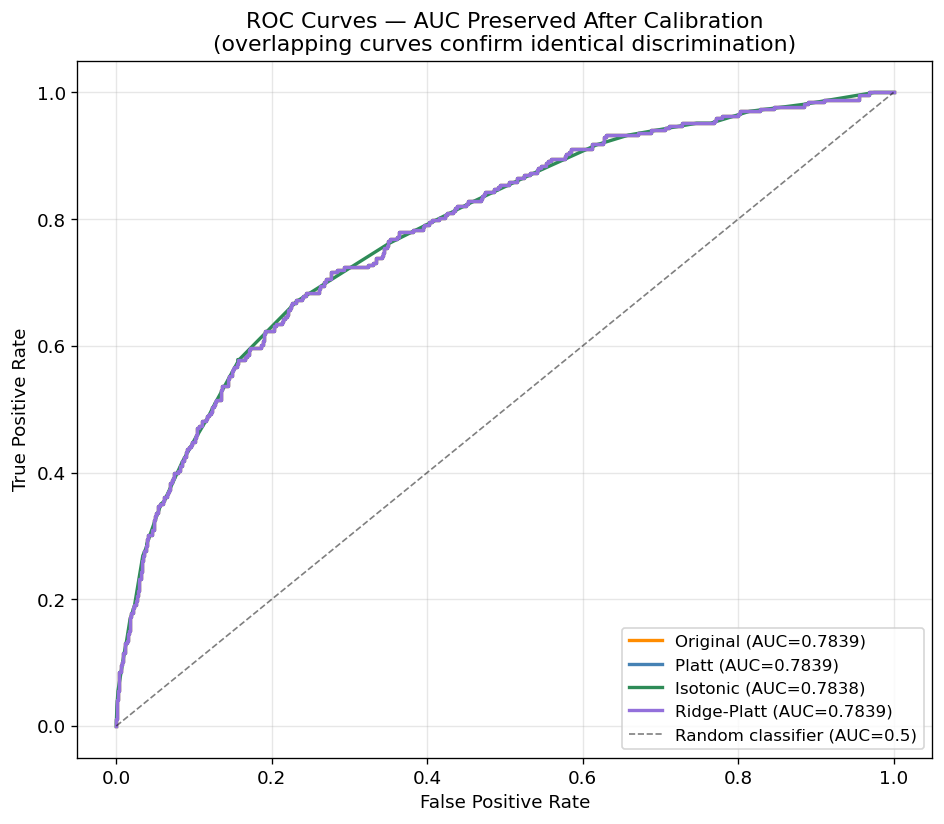

Saved: outputs/plots/07_auc_preservation.png


In [20]:
from sklearn.metrics import roc_auc_score, roc_curve

print("=" * 60)
print("AUC-ROC PRESERVATION CHECK")
print("=" * 60)
print("AUC should be identical before and after calibration.")
print("Calibration changes probability values, not ranking order.")
print()

# Compute AUC for all four conditions on the test set
auc_results = {}

for method_name, scores in [
    ("Original DenseNet-121", s_test),
    ("After Platt Scaling",   s_platt),
    ("After Isotonic Reg.",   s_iso),
    ("After Ridge-Platt",     s_ridge),
]:
    auc = roc_auc_score(y_test, scores)
    auc_results[method_name] = auc
    print(f"{method_name:<30} AUC = {auc:.4f}")

print()
# Check preservation — AUC should not drop by more than 0.001
original_auc = auc_results["Original DenseNet-121"]
print("Preservation check:")
for name, auc in auc_results.items():
    if name == "Original DenseNet-121":
        continue
    diff = abs(auc - original_auc)
    status = "PRESERVED" if diff < 0.005 else "CHANGED — investigate"
    print(f"  {name:<30} diff = {diff:.4f}  → {status}")

print()
print("=" * 60)
print("ACADEMIC STATEMENT")
print("=" * 60)
print(
    f"AUC-ROC was preserved across all calibration methods "
    f"(original AUC = {original_auc:.4f}). "
    f"This confirms that post-hoc calibration corrected "
    f"probability estimates without affecting the model's "
    f"discriminative ability."
)

# Plot ROC curves for all four methods
fig, ax = plt.subplots(figsize=(8, 7))

colors = ["darkorange", "steelblue", "seagreen", "mediumpurple"]
names  = ["Original", "Platt", "Isotonic", "Ridge-Platt"]

for (name, scores), color, short in zip(
    [("Original DenseNet-121", s_test),
     ("After Platt Scaling",   s_platt),
     ("After Isotonic Reg.",   s_iso),
     ("After Ridge-Platt",     s_ridge)],
    colors, names
):
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc         = auc_results[name]
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{short} (AUC={auc:.4f})")

ax.plot([0,1],[0,1],"k--", linewidth=1, alpha=0.5,
        label="Random classifier (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — AUC Preserved After Calibration\n"
             "(overlapping curves confirm identical discrimination)")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/plots/07_auc_preservation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/07_auc_preservation.png")